In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [59]:
df = pd.read_csv("results/benchmark.csv")

df.loc[df["max_depth"] == 0, "factor"] = 0
df["terminal_nodes"] = df["factor"] ** df["max_depth"]
df["terminal_nodes"] = df["terminal_nodes"].clip(upper=df["n"])

# Configuration label for grouping
df["config"] = df.apply(
    lambda r: f"f={r['factor']}, d={r['max_depth']}", axis=1
)

stats = (
    df.groupby(["factor", "max_depth", "terminal_nodes", "config"])["t_total_s"]
    .agg(["mean", "std", "count", "min", "max"])
    .reset_index()
    .sort_values("mean")
)

stats

,factor,max_depth,terminal_nodes,config,mean,std,count,min,max
9,4,3,64,"f=4, d=3",29.1486,8.706395,5,20.566,38.405
5,2,5,32,"f=2, d=5",35.4672,7.278820,5,27.658,42.830
13,32,1,32,"f=32, d=1",35.6022,12.287704,5,21.189,45.813
14,64,1,64,"f=64, d=1",36.6428,7.251942,5,27.700,46.737
11,8,2,64,"f=8, d=2",39.3186,7.288445,5,29.076,48.973
6,2,6,64,"f=2, d=6",39.4656,4.008046,5,33.804,44.646
8,4,2,16,"f=4, d=2",40.5944,7.614238,5,31.246,51.109
12,16,1,16,"f=16, d=1",48.1048,7.743768,5,35.156,55.883
4,2,4,16,"f=2, d=4",48.8574,10.835580,5,37.490,63.190
10,8,1,8,"f=8, d=1",49.9158,7.236035,5,42.658,57.943


## Plot 1: Terminal Nodes vs Total Time 

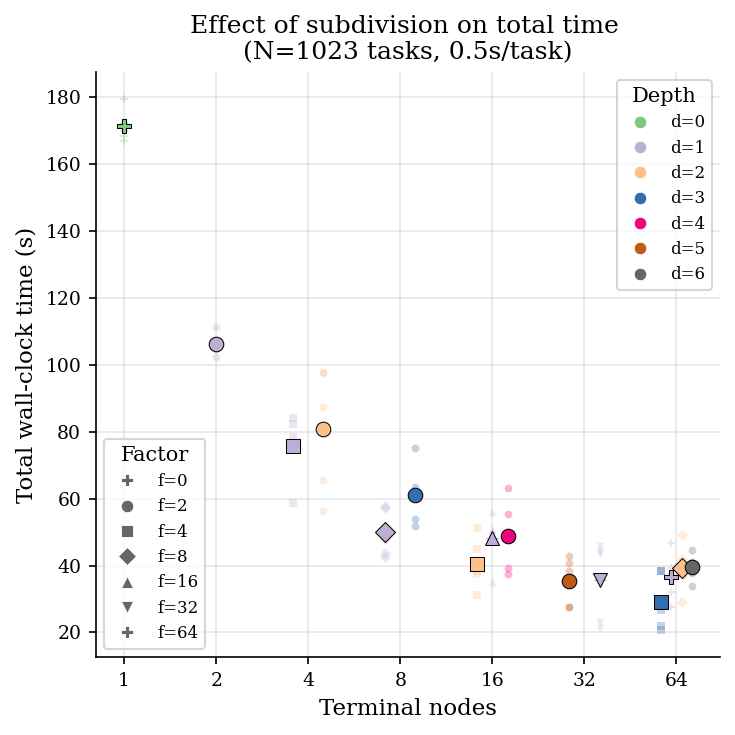

In [67]:
fig, ax = plt.subplots(figsize=(5,5))

depth_cmap = plt.cm.Accent
depth_vals = sorted(df["max_depth"].unique())
depth_norm = plt.Normalize(vmin=min(depth_vals) - 0.5, vmax=max(depth_vals) + 0.5)
factor_markers = {2: "o", 4: "s", 8: "D", 16: "^", 32: "v"}

# For each terminal_nodes value, figure out how many configs share it and assign dodge offsets.
# We work in log2 space so that dodging is proportional to the visual spacing.
tn_groups = stats.groupby("terminal_nodes")
log2_tn_vals = np.log2(stats["terminal_nodes"].unique())
if len(log2_tn_vals) > 1:
    min_gap = np.diff(np.sort(log2_tn_vals)).min()
else:
    min_gap = 1.0
dodge_width = min_gap * 0.33

legend_handles = {}

for tn_val, grp in tn_groups:
    n_configs = len(grp)
    offsets = np.linspace(-dodge_width / 2, dodge_width / 2, n_configs) if n_configs > 1 else [0.0]

    for (_, row), offset in zip(grp.iterrows(), offsets):
        d = int(row["max_depth"])
        f = int(row["factor"])
        color = depth_cmap(depth_norm(d))
        marker = factor_markers.get(f, "P")
        x_center = np.log2(tn_val) + offset

        # Individual runs
        subset = df[(df["factor"] == f) & (df["max_depth"] == d)]
        rng = np.random.default_rng(int(f * 100 + d))
        jitter = rng.uniform(-dodge_width * 0.12, dodge_width * 0.12, len(subset)) *0
        ax.scatter(
            x_center + jitter,
            subset["t_total_s"],
            color=color, alpha=0.3, s=14, linewidths=0,
            marker=marker, zorder=2,
        )

        # Mean + error bar
        h = ax.errorbar(
            x_center, row["mean"], yerr=0,#row["std"],
            fmt=marker, color=color, markersize=7,
            markeredgecolor="black", markeredgewidth=0.5,
            capsize=3, capthick=1, linewidth=1.2, zorder=3,
        )

        # Legend entries: one per depth, one per factor
        depth_key = f"d={d}"
        if depth_key not in legend_handles:
            legend_handles[depth_key] = plt.Line2D(
                [], [], color=color, marker="o", linestyle="",
                markersize=6, markeredgecolor="white", markeredgewidth=0.4,
                label=depth_key,
            )
        factor_key = f"f={f}"
        if factor_key not in legend_handles:
            legend_handles[factor_key] = plt.Line2D(
                [], [], color="0.4", marker=marker, linestyle="",
                markersize=6, markeredgecolor="white", markeredgewidth=0.4,
                label=factor_key,
            )

        # Annotation
        # ax.annotate(
        #     f"f={f}, d={d}",
        #     (x_center, row["mean"]),
        #     textcoords="offset points", xytext=(0, 10),
        #     fontsize=6.5, ha="center", color=color, alpha=0.85,
        #     rotation=30,
        # )

# Format x-axis back to real terminal node values
unique_tn = sorted(stats["terminal_nodes"].unique())
ax.set_xticks(np.log2(unique_tn))
ax.set_xticklabels([str(int(v)) for v in unique_tn])
ax.set_xlabel("Terminal nodes")
ax.set_ylabel("Total wall-clock time (s)")
ax.set_title("Effect of subdivision on total time \n(N=1023 tasks, 0.5s/task)")

# Build legend with two groups
depth_handles = [v for k, v in legend_handles.items() if k.startswith("d=")]
factor_handles = [v for k, v in legend_handles.items() if k.startswith("f=")]
leg1 = ax.legend(handles=depth_handles, title="Depth", loc="upper right", fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=factor_handles, title="Factor", loc="lower left", fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "terminal_nodes_vs_time_dodged.pdf")
fig.savefig(FIGURES_DIR / "terminal_nodes_vs_time_dodged.png")
plt.show()

## Plot 2: Heatmap -- Factor x Max Depth, color = mean total time

Bubble chart where position is (factor, max_depth), color encodes mean runtime, and size encodes number of terminal nodes.

C:\Users\szvsw\AppData\Local\Temp\ipykernel_7200\3100581137.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(v)) if v != 1 else "0" for v in ax.get_xticks()])


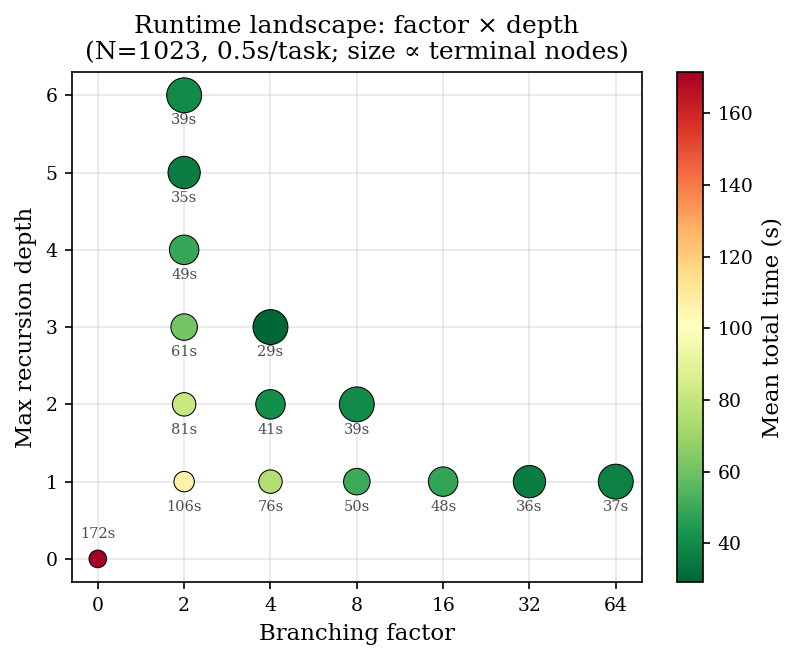

In [87]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

tn_for_size = stats["terminal_nodes"].values
size_scale = 30 + 250 * (np.log2(tn_for_size + 1) / np.log2(tn_for_size.max() + 1))

sc = ax.scatter(
    np.where(stats["factor"] == 0, 1, stats["factor"]),
    stats["max_depth"],
    c=stats["mean"],
    s=size_scale,
    cmap="RdYlGn_r",
    edgecolors="black",
    linewidths=0.5,
    zorder=3,
)

for _, row in stats.iterrows():
    ax.annotate(
        f"{row['mean']:.0f}s",
        (row["factor"] if row["factor"] != 0 else 1, row["max_depth"]),
        textcoords="offset points", xytext=(0, 10 if row["factor"] == 0 else -14),
        fontsize=7, ha="center", color="0.3",
    )

cbar = fig.colorbar(sc, ax=ax, label="Mean total time (s)")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.set_xticklabels([str(int(v)) if v != 1 else "0" for v in ax.get_xticks()])
ax.set_xlabel("Branching factor")
ax.set_ylabel("Max recursion depth")
ax.set_title("Runtime landscape: factor × depth\n(N=1023, 0.5s/task; size ∝ terminal nodes)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "factor_depth_heatmap.pdf")
fig.savefig(FIGURES_DIR / "factor_depth_heatmap.png")
plt.show()

## Plot 3: Bar chart -- configurations ranked by mean total time

Horizontal bar chart with error bars, sorted fastest to slowest. 

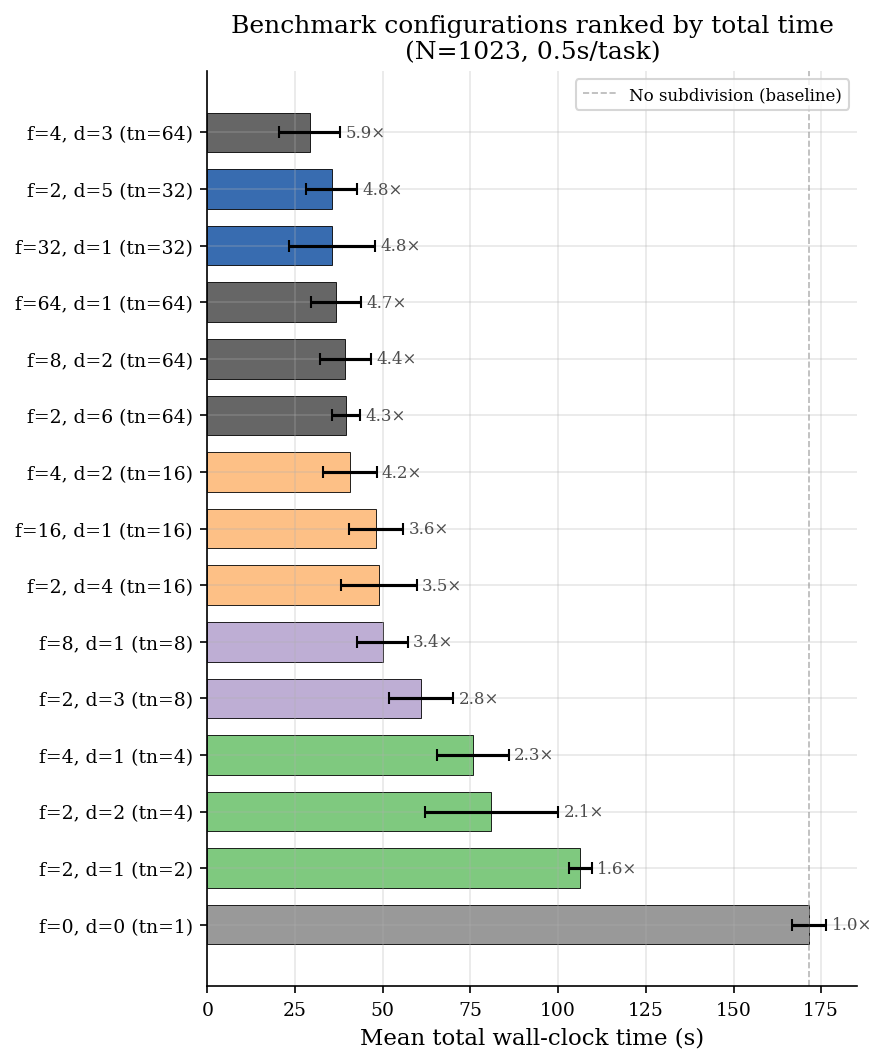

In [70]:
ranked = stats.sort_values("mean", ascending=True).reset_index(drop=True)
baseline_mean = stats[stats["max_depth"] == 0]["mean"].values[0]

fig, ax = plt.subplots(figsize=(6, 0.4 * len(ranked) + 1.2))

colors_bar = []
for _, row in ranked.iterrows():
    if row["max_depth"] == 0:
        colors_bar.append("#999999")
    else:
        colors_bar.append(plt.cm.Accent(row["terminal_nodes"] / ranked["terminal_nodes"].max()))

bars = ax.barh(
    range(len(ranked)), ranked["mean"],
    xerr=ranked["std"],
    color=colors_bar,
    edgecolor="black", linewidth=0.4,
    capsize=3, height=0.7,
)

ax.set_yticks(range(len(ranked)))
ax.set_yticklabels([
    f"f={int(r['factor'])}, d={int(r['max_depth'])} (tn={int(r['terminal_nodes'])})"
    for _, r in ranked.iterrows()
])
ax.invert_yaxis()
ax.set_xlabel("Mean total wall-clock time (s)")
ax.set_title("Benchmark configurations ranked by total time\n(N=1023, 0.5s/task)")

ax.axvline(baseline_mean, color="#999999", linestyle="--", linewidth=0.8, alpha=0.7, label="No subdivision (baseline)")
ax.legend(loc="upper right", fontsize=8)

for i, row in ranked.iterrows():
    speedup = baseline_mean / row["mean"]
    ax.text(
        row["mean"] + row["std"] + 1.5, i,
        f"{speedup:.1f}×",
        va="center", fontsize=8, color="0.3",
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "ranked_configurations.pdf")
fig.savefig(FIGURES_DIR / "ranked_configurations.png")
plt.show()

## Plot 5: Speedup vs Terminal Nodes (normalized to baseline)

Shows the speedup factor (baseline_time / config_time) as a function of terminal nodes. Useful for the paper to quantify the benefit of subdivision.

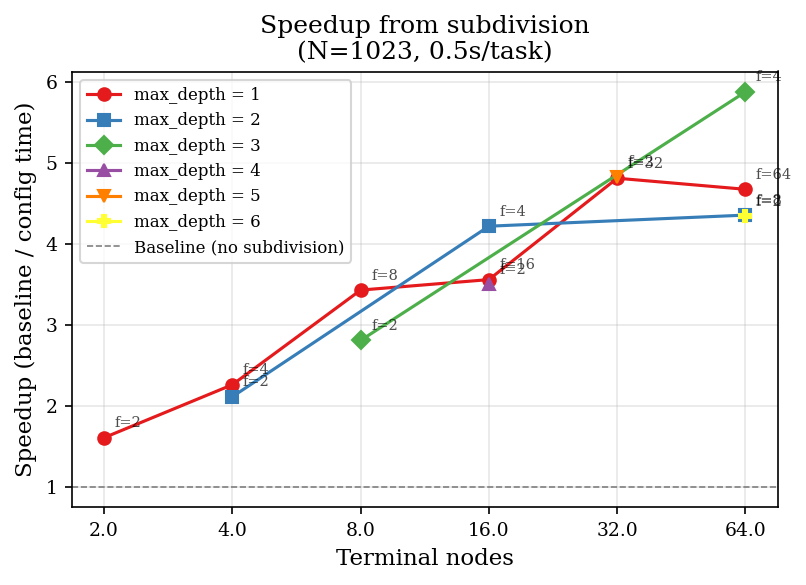

In [86]:
fig, ax = plt.subplots(figsize=(5.5, 4))

stats_sub = stats[stats["max_depth"] > 0].copy()
stats_sub["speedup"] = baseline_mean / stats_sub["mean"]

for i, d in enumerate(sorted(stats_sub["max_depth"].unique())):
    sub = stats_sub[stats_sub["max_depth"] == d].sort_values("terminal_nodes")
    ax.plot(
        sub["terminal_nodes"], sub["speedup"],
        f"-{markers[i % len(markers)]}",
        color=colors[i % len(colors)],
        linewidth=1.5, markersize=6,
        label=f"max_depth = {d}",
    )
    for _, row in sub.iterrows():
        ax.annotate(
            f"f={int(row['factor'])}",
            (row["terminal_nodes"], row["speedup"]),
            textcoords="offset points", xytext=(5, 5),
            fontsize=7, alpha=0.7,
        )

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Baseline (no subdivision)")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel("Terminal nodes")
ax.set_ylabel("Speedup (baseline / config time)")
ax.set_title("Speedup from subdivision\n(N=1023, 0.5s/task)")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "speedup_vs_terminal_nodes.pdf")
fig.savefig(FIGURES_DIR / "speedup_vs_terminal_nodes.png")
plt.show()